# 27 - Mini-batch Size

**Section:** Regularization | **Prereqs:** `Regularization/Regularization_theory.ipynb` | **Next:** `Regularization/Dropuout.ipynb`

Batch size sweep: 2, 4, 8, 16, 32, 64 on Iris, everything else held fixed.

**What batch size actually controls**
- **Updates per epoch** = training-set size / batch size. Batch 2 makes 60
  updates per epoch on Iris; batch 64 makes 2. That alone explains most of what
  you see in the curves - small batches appear to learn 'faster per epoch'
  because they take far more steps per epoch.
- **Gradient noise.** A small batch estimates the true gradient badly. That noise
  is a regulariser: it stops the optimizer settling into sharp minima, which is
  why small batches often generalise slightly better.
- **Hardware efficiency.** Large batches use the GPU better. This, not
  statistics, is why production code uses 32-512.

**The practical answer:** powers of 2 between 16 and 128, and re-tune the
learning rate when you change it - bigger batches take less noisy steps and can
usually take bigger ones.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader , TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [11]:
# Iris, 150 samples. Small enough that batch size makes a visible difference.
iris = load_iris()

data = torch.tensor(iris.data, dtype=torch.float)
label = torch.tensor(iris.target, dtype=torch.long)

In [12]:
# 80/20 split, wrapped as TensorDatasets. Note no loaders yet - the batch size
# is the variable being swept, so the loaders are built inside the loop.
data_train, data_test, label_train, label_test = train_test_split(data,label, test_size=0.20)

train_data = TensorDataset(data_train, label_train)
test_data = TensorDataset(data_test, label_test)

In [19]:
# The training function takes the loaders, so everything except batch size is
# identical across runs: same architecture, lr, epochs and loss.
def train_model(train_loader, test_loader):
  model = nn.Sequential(
     nn.Linear(4,64),   # input layer
     nn.ReLU(),         # activation unit
     nn.Linear(64,64),  # hidden layer
     nn.ReLU(),         # activation unit
     nn.Linear(64,3)
  )

  optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
  lossFunc = nn.CrossEntropyLoss()
  epochs = 500

  losses = torch.zeros(epochs)
  test_acc = []
  train_acc =[]

  for i in range(epochs):

    model.train()
    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100*torch.mean( (torch.argmax(yhat,dim =1 ) == y).float() ).item() )

    losses[i] = np.mean(batch_loss)
    train_acc.append(np.mean(batch_acc))

    model.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      pred = model(X)
      test_acc.append(100* torch.mean( (torch.argmax(pred,dim =1) == Y).float() ).item())

  return test_acc, train_acc, losses

In [20]:
# The sweep: batch sizes 2, 4, 8, 16, 32, 64 (2**1 through 2**6).
# Note the train loader has no shuffle=True, so each run sees the same batch
# composition every epoch - shuffling would add another source of variation.
# The test loader is built once, outside the loop: the evaluation set never
# changes.
bs = 2**np.arange(1,7)

test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

final_test = []
final_train = []
final_loss = []

for i in bs:

  train_loader = DataLoader(train_data, batch_size=int(i))

  test_acc, train_acc, losses = train_model(train_loader,test_loader)

  final_train.append(train_acc)
  final_test.append(test_acc)
  final_loss.append(losses)



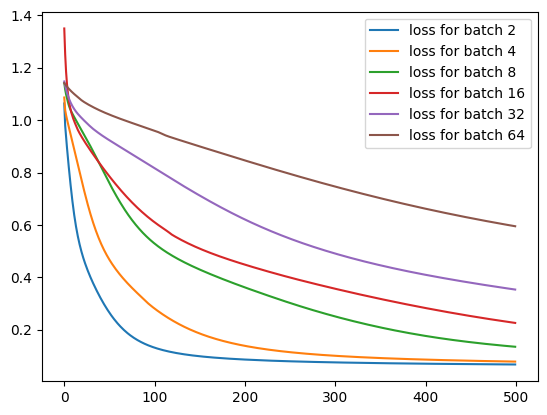

In [21]:
# Loss per epoch for each batch size. Smaller batches show noisier curves that
# drop faster per epoch - because each epoch contains many more updates.
for i in range(6):
  plt.plot(final_loss[int(i)],label=f'loss for batch {bs[i]}')
  plt.legend()

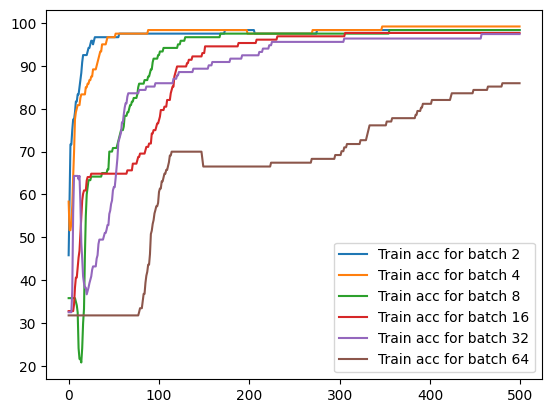

In [22]:
# Train accuracy. Same story: batch 2 converges in far fewer epochs than batch
# 64. Compare per UPDATE rather than per epoch and the gap mostly disappears.
for i in range(6):
  plt.plot(final_train[int(i)],label=f'Train acc for batch {bs[i]}')
  plt.legend()

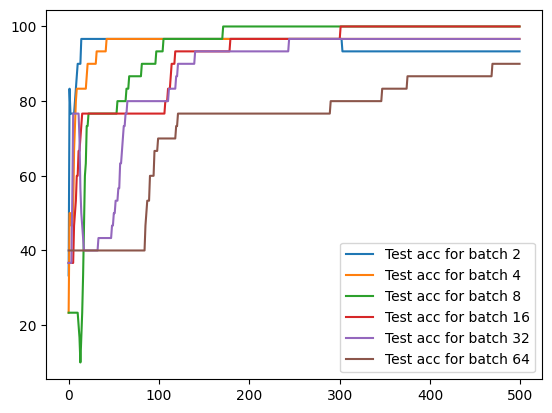

In [23]:
# Test accuracy - the one that decides. The final values usually cluster within
# a couple of points of each other, so on this problem batch size buys speed and
# stability, not accuracy.
for i in range(6):
  plt.plot(final_test[int(i)],label=f'Test acc for batch {bs[i]}')
  plt.legend()